In [1]:
# Import required libraries
import pandas as pd
import dash
from dash import html
from dash import dcc
from dash.dependencies import Input, Output
import plotly.express as px

/Users/marion/Documents/Programming/Study_Data_Analysis/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
spacex_df = pd.read_csv("spacex_launch_dash.csv")

In [3]:
spacex_df.head()      
filtered_df=spacex_df.groupby('Launch Site', as_index=False)['class'].mean()

In [4]:
filtered_df = spacex_df[spacex_df['class'] == 1]
filtered_df=spacex_df.groupby('Launch Site', as_index=False)['class'].sum()
filtered_df

,Launch Site,class
0,CCAFS LC-40,7
1,CCAFS SLC-40,3
2,KSC LC-39A,10
3,VAFB SLC-4E,4


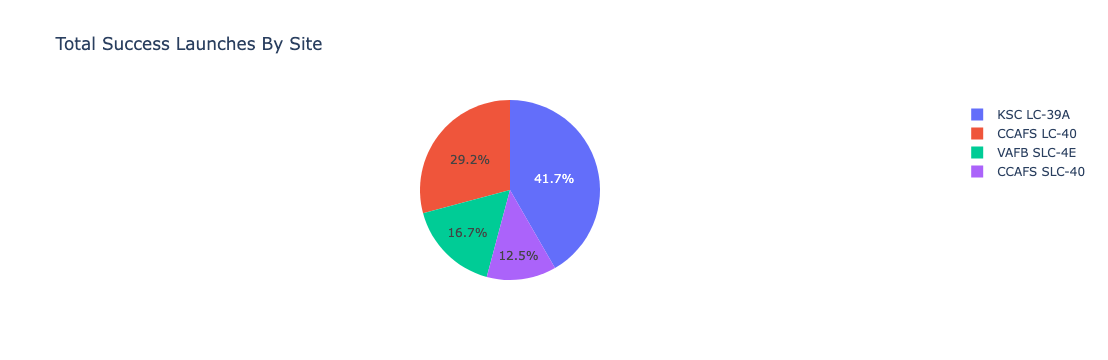

In [5]:
fig = px.pie(filtered_df, values='class', 
names='Launch Site', 
title='Total Success Launches By Site')
fig.show()

In [6]:
spacex_df = pd.read_csv("spacex_launch_dash.csv")
site ='VAFB SLC-4E'
filtered_df = spacex_df[spacex_df['Launch Site'] == site]
filtered_df.head()


,Unnamed: 0,Flight Number,Launch Site,class,Payload Mass (kg),Booster Version,Booster Version Category
26,26,6,VAFB SLC-4E,0,500.0,F9 v1.1 B1003,v1.1
27,27,21,VAFB SLC-4E,0,553.0,F9 v1.1 B1017,v1.1
28,28,29,VAFB SLC-4E,1,9600.0,F9 FT B1029.1,FT
29,29,37,VAFB SLC-4E,1,9600.0,F9 FT B1036.1,FT
30,30,40,VAFB SLC-4E,1,475.0,F9 FT B1038.1,FT


In [7]:

#Calculate the occurence of each class
class0=int(filtered_df[filtered_df['class']==0]['class'].value_counts().iloc[0])
print("0: ",class0)
class1=int(filtered_df[filtered_df['class']==1]['class'].value_counts().iloc[0])
print("1: ", class1)

0:  6
1:  4


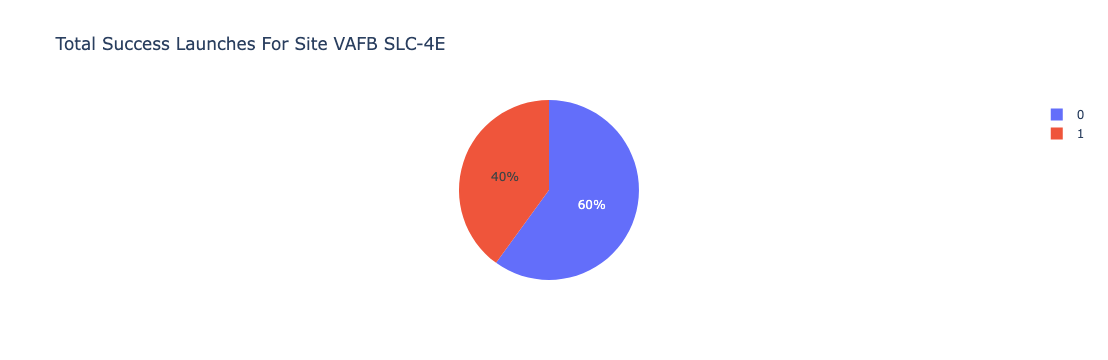

In [8]:
# Prepare the data for the ie chart
data_pie = pd.DataFrame({
    'category': ['0', '1'],
    'values': [class0, class1]
})

# Create the pie chart
fig = px.pie(data_pie, names='category', values='values', title='Total Success Launches For Site ' +site)
fig.show()

In [9]:
spacex_df = pd.read_csv("spacex_launch_dash.csv")
#Calculate success rate for booster category
category=spacex_df['Booster Version Category'].unique()
for cat in category:
    filtered_df = spacex_df[spacex_df['Booster Version Category'] == cat]
    print('Booster Version Category: '+cat +" ", filtered_df['Booster Version Category'].value_counts().iloc[0])
    if 1 in filtered_df ['class'].unique():
        class1=int(filtered_df[filtered_df['class']==1]['class'].value_counts().iloc[0])
        total= filtered_df['Booster Version Category'].value_counts().iloc[0]
        successrate= class1/total*100
    else:
        successrate=0
    print('Booster Version Category success: '+cat +" ", successrate)

Booster Version Category: v1.0  5
Booster Version Category success: v1.0  0
Booster Version Category: v1.1  15
Booster Version Category success: v1.1  6.666666666666667
Booster Version Category: FT  24
Booster Version Category success: FT  66.66666666666666
Booster Version Category: B4  11
Booster Version Category success: B4  54.54545454545454
Booster Version Category: B5  1
Booster Version Category success: B5  100.0


In [10]:
spacex_df = pd.read_csv("spacex_launch_dash.csv")
category=spacex_df['Booster Version Category'].unique()
for cat in category:
    filtered_df = spacex_df[spacex_df['Booster Version Category'] == cat]
    print(filtered_df ['class'].unique())    
    print(filtered_df ['class'].value_counts())
    if 1 in filtered_df ['class'].unique():
        print("OK")
    else:
        print(0)

[0]
class
0    5
Name: count, dtype: int64
0
[0 1]
class
0    14
1     1
Name: count, dtype: int64
OK
[1 0]
class
1    16
0     8
Name: count, dtype: int64
OK
[1 0]
class
1    6
0    5
Name: count, dtype: int64
OK
[1]
class
1    1
Name: count, dtype: int64
OK


In [11]:
def get_pie_chart(entered_site):
    filtered_df = spacex_df
    if entered_site == 'ALL':
        #select only the success launches
        filtered_df = spacex_df[spacex_df['class'] == 1]
        #group by site and calculate the total of success launches
        filtered_df=spacex_df.groupby('Launch Site', as_index=False)['class'].sum()
        fig = px.pie(filtered_df, values='class', 
        names='Launch Site', 
        title='Total Success Launches By Site')
        return fig
    else:
        # return the success rate for a selected site
        filtered_df = spacex_df[spacex_df['Launch Site'] == entered_site]
        #Calculate the occurence of each class
        class0=int(filtered_df[filtered_df['class']==0]['class'].value_counts().iloc[0])
        class1=int(filtered_df[filtered_df['class']==1]['class'].value_counts().iloc[0])
        # Prepare the data for the ie chart
        data_pie = pd.DataFrame({'category': ['0', '1'],'values': [class0, class1]})
        
        # Create the pie chart
        fig = px.pie(data_pie, names='category', values='values', title='Total Success Launches For Site ' +entered_site)
        return fig

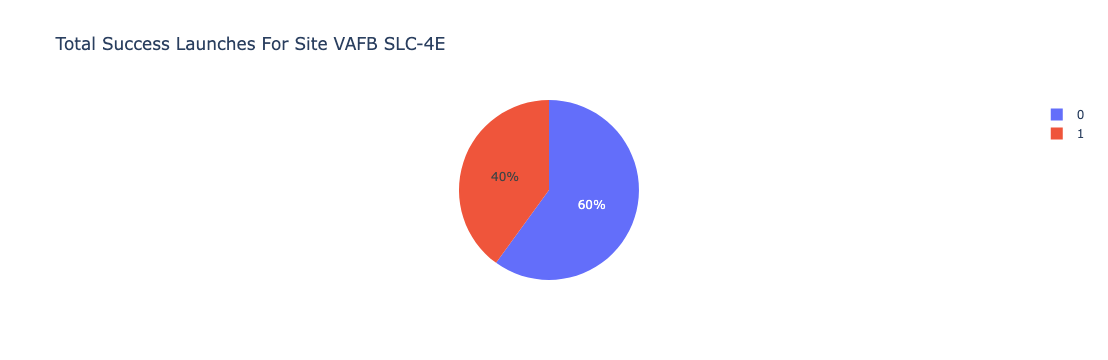

In [12]:
get_pie_chart('VAFB SLC-4E')

In [13]:
def get_scatter_chart(entered_site, slider_range):
    filtered_df = spacex_df
    if entered_site == 'ALL':
        fig = px.scatter(filtered_df, x='Payload Mass (kg)' , y='class', 
        color='Booster Version Category', 
        title='Correlation between Payload and Success')
        fig.update_layout(xaxis=dict(range=slider_range))
        return fig
    else:
        # return the outcomes scatterplot for a selected site
        filtered_df = spacex_df[spacex_df['Launch Site'] == entered_site]
        fig=px.scatter(filtered_df, x='Payload Mass (kg)', y='class', color= 'Booster Version Category', title='Correlation between Payload and Sucess')
        fig.update_layout(xaxis=dict(range=slider_range))
        return fig


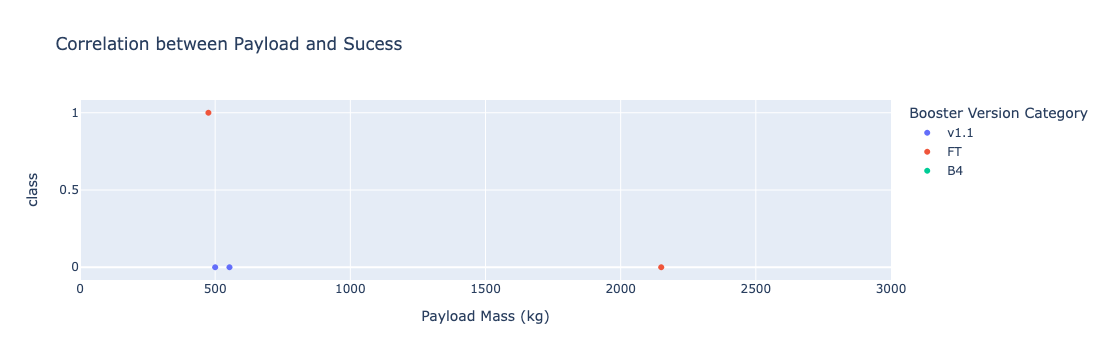

In [14]:
get_scatter_chart('VAFB SLC-4E',[000,3000])

In [15]:
# Import required libraries
import pandas as pd
import dash
from dash import html
from dash import dcc
from dash.dependencies import Input, Output
import plotly.express as px

# Read the airline data into pandas dataframe
spacex_df = pd.read_csv("spacex_launch_dash.csv")
max_payload = spacex_df['Payload Mass (kg)'].max()
min_payload = spacex_df['Payload Mass (kg)'].min()

# Create a dash application
app = dash.Dash(__name__)

# Create an app layout
app.layout = html.Div(children=[html.H1('SpaceX Launch Records Dashboard',
                                        style={'textAlign': 'center', 'color': '#503D36',
                                               'font-size': 40}),
                                # TASK 1: Add a dropdown list to enable Launch Site selection
                                # The default select value is for ALL sites
                                # dcc.Dropdown(id='site-dropdown',...)
                                html.Br(),
                                dcc.Dropdown(id='site-dropdown',
                                options=[
                                    {'label': 'All Sites', 'value': 'ALL'},
                                    {'label': 'CCAFS LC-40', 'value': 'CCAFS LC-40'}, 
                                    {'label': 'CCAFS SLC-40', 'value': 'CCAFS SLC-40'}, 
                                    {'label': 'KSC LC-39A', 'value': 'KSC LC-39A'}, 
                                    {'label': 'VAFB SLC-4E', 'value': 'VAFB SLC-4E'}, 
                                    ],
                                    value='ALL',
                                    placeholder="Select a Launch Site here",
                                    searchable=True
                                    ),

                                # TASK 2: Add a pie chart to show the total successful launches count for all sites
                                # If a specific launch site was selected, show the Success vs. Failed counts for the site
                                html.Div(dcc.Graph(id='success-pie-chart')),
                                html.Br(),


                                html.P("Payload range (Kg):"),
                                # TASK 3: Add a slider to select payload range
                                #dcc.RangeSlider(id='payload-slider',...)
                                dcc.RangeSlider(id='payload-slider', min=0, max=10000, step=1000, 
                                marks={0: '0', 1000: '1000', 5000: '5000', 10000: '10000'}, 
                                value=[min_payload, max_payload]),

                                # TASK 4: Add a scatter chart to show the correlation between payload and launch success
                                html.Div(dcc.Graph(id='success-payload-scatter-chart')),
                                ])

# TASK 2:
# Add a callback function for `site-dropdown` as input, `success-pie-chart` as output

# Function decorator to specify function input and output
@app.callback(Output(component_id='success-pie-chart', component_property='figure'),Input(component_id='site-dropdown', component_property='value'))

def get_pie_chart(entered_site):
    filtered_df = spacex_df
    if entered_site == 'ALL':
        #select only the success launches
        filtered_df = spacex_df[spacex_df['class'] == 1]
        #group by site and calculate the total of success launches
        filtered_df=spacex_df.groupby('Launch Site', as_index=False)['class'].sum()
        fig = px.pie(filtered_df, values='class', 
        names='Launch Site', 
        title='Total Success Launches By Site')
        return fig
    else:
        # return the success rate for a selected site
        filtered_df = spacex_df[spacex_df['Launch Site'] == entered_site]
        #Calculate the occurence of each class
        class0=int(filtered_df[filtered_df['class']==0]['class'].value_counts().iloc[0])
        class1=int(filtered_df[filtered_df['class']==1]['class'].value_counts().iloc[0])
        # Prepare the data for the ie chart
        data_pie = pd.DataFrame({'category': ['0', '1'],'values': [class0, class1]})
        
        # Create the pie chart
        fig = px.pie(data_pie, names='category', values='values', title='Total Success Launches For site ' +entered_site)
        return fig

# TASK 4:
# Add a callback function for `site-dropdown` and `payload-slider` as inputs, `success-payload-scatter-chart` as output
# Function decorator to specify function input and output
@app.callback(Output(component_id='success-payload-scatter-chart', component_property='figure'),[Input(component_id='site-dropdown', component_property='value'), Input(component_id='payload-slider', component_property='value')])

def get_scatter_chart(entered_site, slider_range):
    filtered_df = spacex_df
    if entered_site == 'ALL':
        fig = px.scatter(filtered_df, x='Payload Mass (kg)' , y='class', 
        color='Booster Version Category', 
        title='Correlation between Payload and Success')
        fig.update_layout(xaxis=dict(range=slider_range))
        return fig
    else:
        # return the outcomes scatterplot for a selected site
        filtered_df = spacex_df[spacex_df['Launch Site'] == entered_site]
        fig=px.scatter(filtered_df, x='Payload Mass (kg)', y='class', color= 'Booster Version Category', title='Correlation between Payload and Sucess')
        fig.update_layout(xaxis=dict(range=slider_range))
        return fig

# Run the app
if __name__ == '__main__':
    app.run()


    #the slider does not work, nothing happens when changing it
